## This notebook is used to quantize a trained MNIST model and export weight .coe files for RTL design development.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

%matplotlib inline
np.random.seed(1)
torch.manual_seed(1)
if torch.cuda.is_available():
	torch.cuda.manual_seed(1)
	torch.cuda.manual_seed_all(1)

In [2]:
import torchvision.datasets as datasets

# Load MNIST test data (PyTorch equivalent)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)
X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

### Define CNN Model Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import torch

import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,6,3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(6,16,3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2,2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(400,10)

    def forward(self,x):

        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = self.flatten(x)
        x = self.fc(x)

        return x


NameError: name 'create_simple_cnn' is not defined

### Train and Evaluate CNN Model

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST dataset
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

x_train = mnist_train.data.float() / 255.0
y_train = mnist_train.targets

x_test  = mnist_test.data.float() / 255.0
y_test  = mnist_test.targets

# Normalize and reshape
x_train = x_train.unsqueeze(1)   # shape: (60000, 1, 28, 28)
x_test  = x_test.unsqueeze(1)

# Create model
model = model = CNN()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

# Train
epochs = 40
batch_size = 1000
train_loader = DataLoader(list(zip(x_train, y_train)), batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

# Evaluate
test_loader = DataLoader(list(zip(x_test, y_test)), batch_size=batch_size)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total
print(f"Test accuracy: {test_acc * 100:.2f}%")

Test accuracy: 98.44%


### Quantized CNN Model for MNIST with PyTorch 

In [ ]:

import torch.nn as nn
import torch.quantization as quant

class QuantCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.quant = quant.QuantStub()

        self.conv1 = nn.Conv2d(1,6,3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(6,16,3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2,2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(400,10)

        self.dequant = quant.DeQuantStub()

    def forward(self,x):

        x = self.quant(x)

        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = self.flatten(x)
        x = self.fc(x)

        x = self.dequant(x)

        return x

### Load pretrain weights from previous train model

In [ ]:
quant_model = QuantCNN()
quant_model.load_state_dict(model.state_dict())
quant_model.eval()

QuantCNN(
  (quant): QuantStub()
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=400, out_features=10, bias=True)
  (dequant): DeQuantStub()
)

### Choosing quantization configuration

In [ ]:
quant_model.qconfig = torch.quantization.get_default_qconfig('fbgemm')

### Preparing model

In [ ]:

torch.quantization.prepare(quant_model, inplace=True)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


QuantCNN(
  (quant): QuantStub(
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (conv1): Conv2d(
    1, 6, kernel_size=(3, 3), stride=(1, 1)
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(
    6, 16, kernel_size=(3, 3), stride=(1, 1)
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(
    in_features=400, out_features=10, bias=True
    (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
  )
  (dequant): DeQuantStub()
)

### Performing caliberation with mnist dataset to collect statistics for quantization

In [13]:
with torch.no_grad():
    for i, (images, labels) in enumerate(train_loader):

        quant_model(images)

        if i > 5:
            break

### Convert into INT8 representation 

In [ ]:
torch.quantization.convert(quant_model, inplace=True)

QuantCNN(
  (quant): Quantize(scale=tensor([0.0079]), zero_point=tensor([0]), dtype=torch.quint8)
  (conv1): QuantizedConv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), scale=0.05209114030003548, zero_point=47)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): QuantizedConv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), scale=0.16954950988292694, zero_point=67)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): QuantizedLinear(in_features=400, out_features=10, scale=0.42191600799560547, zero_point=64, qscheme=torch.per_channel_affine)
  (dequant): DeQuantize()
)

In [15]:
# Assuming quant_model is a quantized PyTorch model
w_1 = quant_model.conv1.weight()

print(w_1.q_per_channel_scales())
print(w_1.q_per_channel_zero_points())
print(quant_model.conv1.bias())  # Access bias from the layer, not the weight tensor

tensor([0.0032, 0.0047, 0.0046, 0.0049, 0.0043, 0.0070], dtype=torch.float64)
tensor([0, 0, 0, 0, 0, 0])
Parameter containing:
tensor([ 3.5902e-01,  2.7400e-01, -1.1728e-04, -1.9234e-02,  1.0843e-03,
         2.5520e-01], requires_grad=True)


In [16]:
w_2 = quant_model.conv2.weight()

print(w_2.q_per_channel_scales())
print(w_2.q_per_channel_zero_points())

tensor([0.0062, 0.0043, 0.0050, 0.0047, 0.0043, 0.0046, 0.0030, 0.0053, 0.0011,
        0.0035, 0.0034, 0.0047, 0.0036, 0.0050, 0.0041, 0.0037],
       dtype=torch.float64)
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [17]:
w_fc = quant_model.fc.weight()

print(w_fc.q_per_channel_scales())
print(w_fc.q_per_channel_zero_points())

tensor([0.0029, 0.0044, 0.0032, 0.0027, 0.0028, 0.0044, 0.0028, 0.0041, 0.0042,
        0.0040], dtype=torch.float64)
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


### Performing accuracy evaluaton of quantized model, comparing it with FP32 model

In [19]:
print(f"Number of images in test set: {len(x_test)}")

Number of images in test set: 10000


In [22]:
# Evaluate both models on the test set
quant_model.eval()

with torch.no_grad():
    # Original FP32 model
    outputs_fp32 = model(x_test)
    pred_fp32 = torch.argmax(outputs_fp32, dim=1)
    acc_fp32 = (pred_fp32 == y_test).float().mean().item()
    
    # Quantized INT8 model
    outputs_int8 = quant_model(x_test)
    pred_int8 = torch.argmax(outputs_int8, dim=1)
    acc_int8 = (pred_int8 == y_test).float().mean().item()

print(f"FP32 Model Test Accuracy: {acc_fp32 * 100:.2f}%")
print(f"INT8 Quantized Model Test Accuracy: {acc_int8 * 100:.2f}%")
print(f"Accuracy Difference: {(acc_fp32 - acc_int8) * 100:.2f}%")

# Find examples where predictions differ
diff_indices = torch.where(pred_fp32 != pred_int8)[0]
if len(diff_indices) > 0:
    print(f"\nNumber of differing predictions: {len(diff_indices)}")
    print("First 5 differing examples:")
    for i in range(min(5, len(diff_indices))):
        idx = diff_indices[i].item()
        print(f"  Index {idx}: True label {y_test[idx].item()}, FP32 pred {pred_fp32[idx].item()}, INT8 pred {pred_int8[idx].item()}")
else:
    print("\nAll predictions match!")

FP32 Model Test Accuracy: 98.44%
INT8 Quantized Model Test Accuracy: 98.39%
Accuracy Difference: 0.05%

Number of differing predictions: 25
First 5 differing examples:
  Index 320: True label 9, FP32 pred 9, INT8 pred 8
  Index 740: True label 4, FP32 pred 9, INT8 pred 4
  Index 958: True label 3, FP32 pred 3, INT8 pred 0
  Index 965: True label 6, FP32 pred 6, INT8 pred 0
  Index 1192: True label 9, FP32 pred 9, INT8 pred 7


### Exporting coe files for INT8 weights from quantized model

In [42]:
def write_coe(path, data):
    with open(path, "w") as f:
        f.write("memory_initialization_radix=10;\n")
        f.write("memory_initialization_vector=\n")

        for i, val in enumerate(data):
            if i < len(data) - 1:
                f.write(f"{int(val)},\n")
            else:
                f.write(f"{int(val)};\n")

    print("Saved", path)

In [43]:
def export_fc(layer, name, folder):
    """
    Export Linear weights (no partition)

    One file per neuron
    """

    w = layer.weight()
    w_int8 = w.int_repr().cpu().numpy()

    out_f, in_f = w_int8.shape

    fc_dir = os.path.join(folder, name)
    os.makedirs(fc_dir, exist_ok=True)

    for o in range(out_f):
        data = w_int8[o].astype(int).tolist()

        path = os.path.join(fc_dir, f"{name}_n{o}.coe")
        write_coe(path, data)

In [44]:
def export_conv(layer, name, folder):
    """
    Export quantized Conv2d weights to COE files.

    Output format:
        convx_fx_inx.coe

    Examples:
        conv1_f0_in0.coe
        conv2_f3_in5.coe

    Data layout inside each file:
        flattened in (kh, kw) order

    For a 3x3 kernel, each file contains 9 values:
        w[f, in_ch, 0,0], w[f, in_ch, 0,1], ..., w[f, in_ch, 2,2]
    """

    import os

    w = layer.weight()                    # quantized weight tensor
    w_int8 = w.int_repr().cpu().numpy()  # integer representation

    out_ch, in_ch, kH, kW = w_int8.shape

    for f in range(out_ch):
        for c in range(in_ch):
            data = []

            # kernel traversal order
            for kh in range(kH):
                for kw in range(kW):
                    data.append(int(w_int8[f, c, kh, kw]))

            path = os.path.join(folder, f"{name}_f{f}_in{c}.coe")
            write_coe(path, data)

In [46]:
import os
import numpy as np
import torch
import torch.nn as nn


def quantize_multiplier(real_multiplier):
    """
    Convert real multiplier to integer M0 and right shift n
    such that:
        real_multiplier ≈ M0 / 2^(31+n)
    with M0 in Q0.31
    """
    if real_multiplier == 0:
        return 0, 0

    n = 0
    while real_multiplier < 0.5:
        real_multiplier *= 2.0
        n += 1

    M0 = int(round(real_multiplier * (1 << 31)))

    # handle rare corner case caused by rounding
    if M0 == (1 << 31):
        M0 //= 2
        n -= 1

    return M0, n


def tensor_to_list(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy().reshape(-1).tolist()
    elif isinstance(x, np.ndarray):
        return x.reshape(-1).tolist()
    elif isinstance(x, (list, tuple)):
        return list(x)
    else:
        return [x]


def get_weight_qparams(layer):
    """
    Return weight scales and zero-points as Python lists.
    Supports both per-tensor and per-channel quantized weights.
    """
    w = layer.weight()
    qscheme = w.qscheme()

    if qscheme == torch.per_tensor_affine or qscheme == torch.per_tensor_symmetric:
        w_scales = [float(w.q_scale())]
        w_zps    = [int(w.q_zero_point())]
        per_channel = False

    elif qscheme == torch.per_channel_affine or qscheme == torch.per_channel_symmetric:
        w_scales = w.q_per_channel_scales().detach().cpu().numpy().astype(np.float64).tolist()
        w_zps    = w.q_per_channel_zero_points().detach().cpu().numpy().astype(np.int64).tolist()
        per_channel = True

    else:
        raise RuntimeError(f"Unsupported weight qscheme: {qscheme}")

    return qscheme, per_channel, w_scales, w_zps


def format_num_list(vals):
    return " ".join(str(v) for v in vals)


def format_hex_list(vals, width=8):
    return " ".join(f"0x{int(v) & ((1 << (width*4)) - 1):0{width}X}" for v in vals)


def export_quant_params(layer, name, file, input_scale, input_zero_point):
    """
    Export quantization report for one quantized layer.
    Handles per-channel weight quantization correctly.
    """

    qscheme, per_channel, w_scales, w_zps = get_weight_qparams(layer)

    out_scale = float(layer.scale)
    out_zp    = int(layer.zero_point)

    bias = layer.bias()
    if bias is None:
        bias_list = []
    else:
        # PyTorch quantized bias is stored in float, but numerically it corresponds
        # to bias / (input_scale * weight_scale) in the integer pipeline.
        bias_fp = bias.detach().cpu().numpy().astype(np.float64).reshape(-1)

        if per_channel:
            bias_int = np.round(bias_fp / (input_scale * np.array(w_scales))).astype(np.int64).tolist()
        else:
            bias_int = np.round(bias_fp / (input_scale * w_scales[0])).astype(np.int64).tolist()

    # multiplier per output channel / filter / neuron
    if per_channel:
        real_multipliers = [(input_scale * ws) / out_scale for ws in w_scales]
        M0_list = []
        n_list = []
        for rm in real_multipliers:
            M0, n = quantize_multiplier(rm)
            M0_list.append(M0)
            n_list.append(n)
    else:
        rm = (input_scale * w_scales[0]) / out_scale
        M0, n = quantize_multiplier(rm)
        out_ch = len(bias_int) if len(bias_int) > 0 else 1
        real_multipliers = [rm] * out_ch
        M0_list = [M0] * out_ch
        n_list  = [n] * out_ch
        w_scales = [w_scales[0]] * out_ch
        w_zps    = [w_zps[0]] * out_ch

    file.write(f"{name.upper()}:\n")
    file.write(f"input_scale: {input_scale}\n")
    file.write(f"output_scale: {out_scale}\n")
    file.write(f"input_zero_point: {input_zero_point}\n")
    file.write(f"output_zero_point: {out_zp}\n")
    file.write(f"weight_qscheme: {str(qscheme)}\n")
    file.write(f"per_channel: {per_channel}\n")

    file.write(f"weight_scale: {format_num_list(w_scales)}\n")
    file.write(f"weight_zero_point: {format_num_list(w_zps)}\n")

    if len(bias_int) > 0:
        file.write(f"bias: {format_num_list(bias_int)}\n")
    else:
        file.write("bias:\n")

    file.write(f"M0: {format_hex_list(M0_list)}\n")
    file.write(f"n: {format_num_list(n_list)}\n\n")

    return out_scale, out_zp


def export_quant_model(model, folder="NEW_INT8_coe_files", input_scale=0.0079, input_zero_point=0):
    os.makedirs(folder, exist_ok=True)
    report_path = os.path.join(folder, "report INT8.txt")

    conv_id = 1
    fc_id = 0

    cur_scale = input_scale
    cur_zp = input_zero_point

    with open(report_path, "w") as f:
        f.write("INPUT:\n")
        f.write(f"scale: {cur_scale}\n")
        f.write(f"zero_point: {cur_zp}\n\n")

        for layer in model.modules():
            if isinstance(layer, torch.nn.quantized.Conv2d):
                name = f"conv{conv_id}"

                export_conv(layer, name, folder)
                cur_scale, cur_zp = export_quant_params(layer, name, f, cur_scale, cur_zp)

                conv_id += 1

            elif isinstance(layer, torch.nn.quantized.Linear):
                name = f"fc{fc_id}"

                export_fc(layer, name, folder)
                cur_scale, cur_zp = export_quant_params(layer, name, f, cur_scale, cur_zp)

                fc_id += 1

    print(f"Saved report to {report_path}")

In [47]:
export_quant_model(quant_model)

Saved NEW_INT8_coe_files\conv1_f0_in0.coe
Saved NEW_INT8_coe_files\conv1_f1_in0.coe
Saved NEW_INT8_coe_files\conv1_f2_in0.coe
Saved NEW_INT8_coe_files\conv1_f3_in0.coe
Saved NEW_INT8_coe_files\conv1_f4_in0.coe
Saved NEW_INT8_coe_files\conv1_f5_in0.coe
Saved NEW_INT8_coe_files\conv2_f0_in0.coe
Saved NEW_INT8_coe_files\conv2_f0_in1.coe
Saved NEW_INT8_coe_files\conv2_f0_in2.coe
Saved NEW_INT8_coe_files\conv2_f0_in3.coe
Saved NEW_INT8_coe_files\conv2_f0_in4.coe
Saved NEW_INT8_coe_files\conv2_f0_in5.coe
Saved NEW_INT8_coe_files\conv2_f1_in0.coe
Saved NEW_INT8_coe_files\conv2_f1_in1.coe
Saved NEW_INT8_coe_files\conv2_f1_in2.coe
Saved NEW_INT8_coe_files\conv2_f1_in3.coe
Saved NEW_INT8_coe_files\conv2_f1_in4.coe
Saved NEW_INT8_coe_files\conv2_f1_in5.coe
Saved NEW_INT8_coe_files\conv2_f2_in0.coe
Saved NEW_INT8_coe_files\conv2_f2_in1.coe
Saved NEW_INT8_coe_files\conv2_f2_in2.coe
Saved NEW_INT8_coe_files\conv2_f2_in3.coe
Saved NEW_INT8_coe_files\conv2_f2_in4.coe
Saved NEW_INT8_coe_files\conv2_f2_

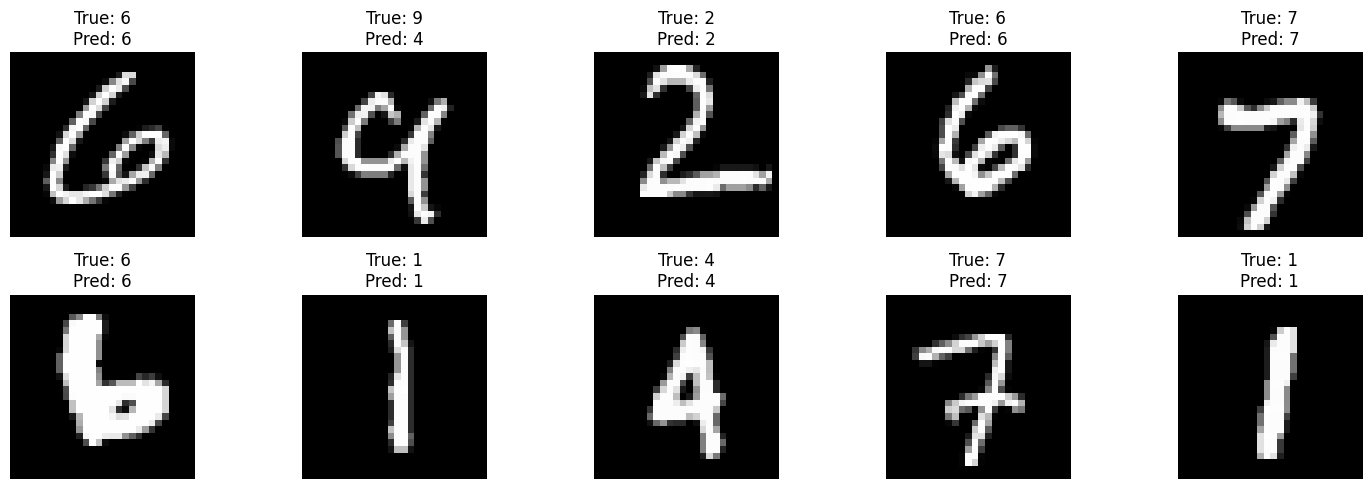

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import torch

num_images = 10
indices = np.random.choice(len(x_test), num_images, replace=False)

with torch.no_grad():
    outputs = quant_model(x_test[indices])
    pred_labels = torch.argmax(outputs, dim=1)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze().numpy(), cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {pred_labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()